# TP - DLA - Privacy defense (I) - defense against MIA

The goal of this practical session is to implement a simple defense against privacy attacks on a simple network.
In this notebook, we focus on noise injection against membership inference attack.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
from scipy.stats import gaussian_kde

In [2]:
# =====================================================
# Parameters (easy to tweak)
# =====================================================
NOISE_STD = 0.8       # standard deviation of Gaussian noise added to logits
TRAIN_SIZE = 100     # train on small subset -> encourage memorization
EPOCHS = 10
BATCH_SIZE = 32
LR = 1e-3
SEED = 42
# =====================================================

torch.manual_seed(SEED)

## Training the model

In this cell, we provide the code for training a simple MLP model, trained for only 15 epochs on 100 samples.

In [3]:
# -------------------------------
# 1. Load MNIST
# -------------------------------
transform = transforms.Compose([transforms.ToTensor()])
full_train = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# smaller training subset
train_subset = torch.utils.data.Subset(full_train, list(range(TRAIN_SIZE)))
train_loader = torch.utils.data.DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
train_loader_eval = torch.utils.data.DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# -------------------------------
# 2. Define small MLP
# -------------------------------
class SmallNet(nn.Module):
    def __init__(self):
        super(SmallNet, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
    def forward(self, x):
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = SmallNet().to(device)

# -------------------------------
# 3. Train model
# -------------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

print("Training model...")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        logits = model(data)
        loss = criterion(logits, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{EPOCHS}, loss={total_loss/len(train_loader):.4f}")


Training model...
Epoch 1/10, loss=2.2814
Epoch 2/10, loss=2.1673
Epoch 3/10, loss=2.0612
Epoch 4/10, loss=1.9364
Epoch 5/10, loss=1.7780
Epoch 6/10, loss=1.6699
Epoch 7/10, loss=1.2851
Epoch 8/10, loss=1.2960
Epoch 9/10, loss=1.0269
Epoch 10/10, loss=0.9668


# Noise injection
In this part, we only emulate a DP mechanisms by adding some noise to the logits of the model (taking care to normalise the result with a softmax).
To achieve this result, we modify the function get_confidence (from the previous practial session).

In [4]:
# -------------------------------
# 4. Helper to collect confidences
# -------------------------------
def get_confidences(model, loader, noise_std=0.0):
    model.eval()
    confs = []
    with torch.no_grad():
        for data, _ in loader:
            data = data.to(device)
            logits = model(data)
            if noise_std > 0:
                logits = logits + noise_std * torch.randn_like(logits)
            probs = F.softmax(logits, dim=1)
            max_probs, _ = probs.max(dim=1)
            confs.extend(max_probs.cpu().numpy())
    return np.array(confs)

# Collect train/test confidences
train_confs_no_dp = get_confidences(model, train_loader_eval, noise_std=0.0)
test_confs_no_dp  = get_confidences(model, test_loader,        noise_std=0.0)

train_confs_dp = get_confidences(model, train_loader_eval, noise_std=NOISE_STD)
test_confs_dp  = get_confidences(model, test_loader,        noise_std=NOISE_STD)



# Plotting the results

Train mean conf (no DP): 0.5238702
Test  mean conf (no DP): 0.42156827


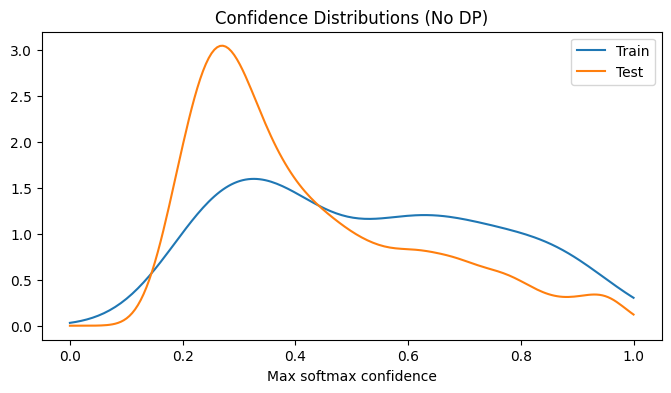

Train mean conf (DP): 0.5291847
Test  mean conf (DP): 0.4593755


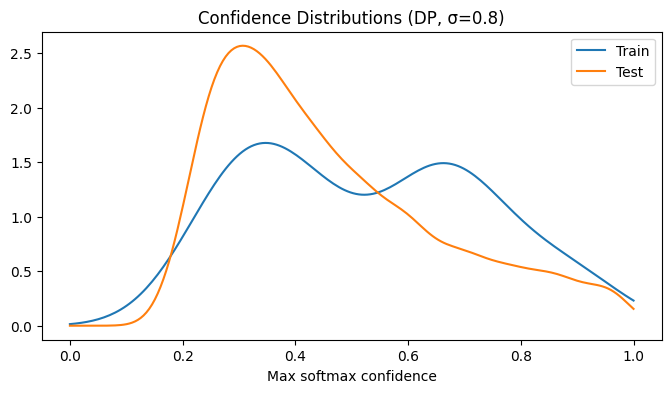

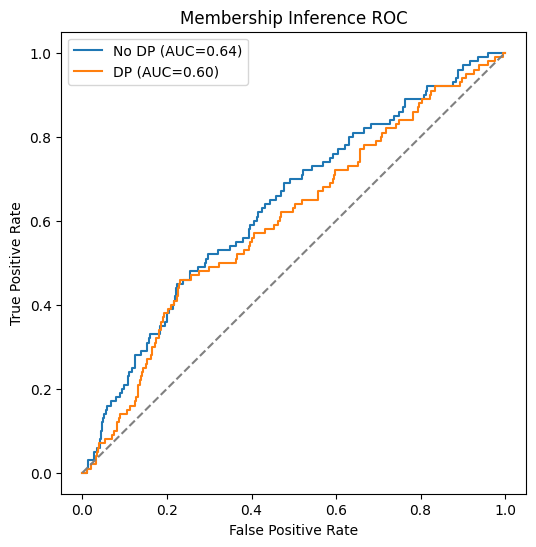

MIA AUC (No DP): 0.635
MIA AUC (DP, σ=0.8): 0.599


In [5]:
# -------------------------------
# 5. Plot confidence distributions
# -------------------------------
def plot_conf_dens(train_confs, test_confs, title):
    xs = np.linspace(0,1,200)
    plt.figure(figsize=(8,4))
    try:
        dtrain = gaussian_kde(train_confs)
        dtest  = gaussian_kde(test_confs)
        plt.plot(xs, dtrain(xs), label="Train")
        plt.plot(xs, dtest(xs), label="Test")
    except Exception:
        plt.hist(train_confs, bins=20, alpha=0.6, label="Train")
        plt.hist(test_confs, bins=20, alpha=0.6, label="Test")
    plt.xlabel("Max softmax confidence")
    plt.title(title)
    plt.legend()
    plt.show()

print("Train mean conf (no DP):", train_confs_no_dp.mean())
print("Test  mean conf (no DP):", test_confs_no_dp.mean())
plot_conf_dens(train_confs_no_dp, test_confs_no_dp, "Confidence Distributions (No DP)")

print("Train mean conf (DP):", train_confs_dp.mean())
print("Test  mean conf (DP):", test_confs_dp.mean())
plot_conf_dens(train_confs_dp, test_confs_dp, f"Confidence Distributions (DP, σ={NOISE_STD})")

# -------------------------------
# 6. ROC curves for Membership Inference
# -------------------------------
def compute_roc_auc(train_confs, test_confs):
    labels = np.concatenate([np.ones_like(train_confs), np.zeros_like(test_confs)])
    scores = np.concatenate([train_confs, test_confs])
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc

fpr_non, tpr_non, auc_non = compute_roc_auc(train_confs_no_dp, test_confs_no_dp)
fpr_dp,  tpr_dp,  auc_dp  = compute_roc_auc(train_confs_dp,    test_confs_dp)

plt.figure(figsize=(6,6))
plt.plot(fpr_non, tpr_non, label=f"No DP (AUC={auc_non:.2f})")
plt.plot(fpr_dp,  tpr_dp,  label=f"DP (AUC={auc_dp:.2f})")
plt.plot([0,1],[0,1],"--",color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Membership Inference ROC")
plt.legend()
plt.show()

print(f"MIA AUC (No DP): {auc_non:.3f}")
print(f"MIA AUC (DP, σ={NOISE_STD}): {auc_dp:.3f}")
